## Experiment Tutorial: Two Qubits

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InteractionType,
    QubitInteraction,
    InitialStateConfig,
    InitialStateType,
    NoiseConfiguration
)
from qsopt.core.circuit import QuantumCircuit, create_ry_circuit_layer
from qsopt.core.experiment.experiment import Experiment

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Setup Experimental Parameters

In [2]:
# Define experimental parameters using nested configuration objects
gm = 0.03 * 2 * np.pi
inverse_pulse_width = 0.1 * gm

interaction = QubitInteraction(
    qubit_indices=(0, 1),
    interaction_type=InteractionType.XX,
    chi=0.1
)

physical_constants = PhysicalConstants(
    n_qubits=2,
    chi=[30.0, 30.0],
    photon_cavity_coupling=15.0,
    inverse_pulse_width=inverse_pulse_width,
    qubit_interactions=[interaction]
)

system_dims = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2, 2]
)

measurement = MeasurementProtocol(
    measurement_times=list(np.array([-6.0, -2.0, 2.0, 6.0])/inverse_pulse_width) 
)

initial_state = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

noise_config = NoiseConfiguration(
    depolarizing=[0.0, 0.0],
    dephasing=[0.0, 0.0],
    relaxation=[0.0, 0.0]
)

exp_params = ExperimentalParameters(
    physical_constants=physical_constants,
    system_dims=system_dims,
    measurement=measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_params)

SYSTEM DIMENSIONS
  Number of qubits:          2
  Cavity levels:             2
  Qubit levels:         [2, 2]
  Field levels:              2
  Total dimension:          16
PHYSICAL CONSTANTS
  Chi:                  [30.0, 30.0]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    0.0188
  Qubit interactions:   1 interaction(s)
    [0] Qubits (0, 1): sx-sx, χ=0.1000
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      4
  Measurement times:    [-318.3098861837907, -106.1032953945969, 106.1032953945969, 318.3098861837907]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0, 0.0]
  Dephasing rate:       [0.0, 0.0]
  Relaxation rate:      [0.0, 0.0]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## 2. Setup Trainable Parameters

For two-qubit experiments, we need 4 rotation angles:
- θ1_q1, θ2_q1: Rotation angles for qubit 1
- θ1_q2, θ2_q2: Rotation angles for qubit 2

In [3]:
# Create Circuit with 4 rotation angles

initial_circuit = create_ry_circuit_layer(n_qubits=2,
        theta_values=np.pi/2)
final_circuit = create_ry_circuit_layer(n_qubits=2,
        theta_values=-np.pi/2)

import optax
optimizer = optax.sgd(learning_rate=1.)

print(initial_circuit)
print(final_circuit)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


QuantumCircuit(2 qubits, 2 gates)
  0: RY(1.5708)[0][0]
  1: RY(1.5708)[1][1]
QuantumCircuit(2 qubits, 2 gates)
  0: RY(-1.5708)[0][0]
  1: RY(-1.5708)[1][1]


## 3. Create Two-Qubit Experiment

Initialize the experiment with our parameters. This will:
- Generate operators for the 4-subsystem composite space
- Build the time-dependent Hamiltonian
- Cache initial state and projectors

In [4]:
experiment = Experiment(exp_params, initial_circuit, final_circuit)

## 4. Run Basic Simulation

In [5]:
# Run simulation with zero rotations
callback = experiment.run_simulation(batch_size=1)

print(callback)

TypeError: Error interpreting argument to <function Experiment.simulation at 0x778466f3f2e0> as an abstract array. The problematic value is of type <class 'qsopt.core.experiment.experiment.Experiment'> and was passed to the function at path self.
This typically means that a jit-wrapped function was called with a non-array argument, and this argument was not marked as static using the static_argnums or static_argnames parameters of jax.jit.

## 5. Optimize Rotation Angles

Now let's optimize the four rotation angles to maximize sensing contrast. By default, the optimization maximizes the detection probability `1 - P(00)` (any outcome except ground state).


In [ ]:
# Optimize with default detection criterion (1 - P(00))
callback_opt = experiment.optimize_rotations(
    num_steps=5,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=20,
    initial_values=[np.pi/3, np.pi/4,-np.pi/3, -np.pi],
    renormalize_grad=False,
    optimizer=optax.sgd(learning_rate=0.5)
)


Configuration:
    Max iterations: 5
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection criterion: any excited
    Trainable parameters: 4 (2 initial circuit + 2 final circuit)
    Initial parameter values:
        param0. setup_=1.047 rad (60.0°)
        param1. setup_=0.785 rad (45.0°)
        param2. reset_=-1.047 rad (-60.0°)
        param3. reset_=-3.142 rad (-180.0°)
Step  setup_0     setup_1     reset_0     reset_1     Contrast    Grad Norm
---------------------------------------------------------------------------
0     1.047198    0.785398    -1.047198   -3.141593   -0.000302   3.26e-02    
Final gradient norm: 5.97e-02
Best sensing contrast: 0.003368
Best parameters:
    param0. setup_[name]=1.041 rad (59.6°)
    param1. setup_[name]=0.839 rad (48.1°)
    param2. reset_[name]=-1.045 rad (-59.9°)
    param3. reset_[name]=-3.081 rad (-176.5°)




opt_start                        :  0.009229
define_obj_func                  :  0.000002
verbose_pretrain          

### Visualize Optimization Progress

Let's plot how the contrast evolved during optimization:


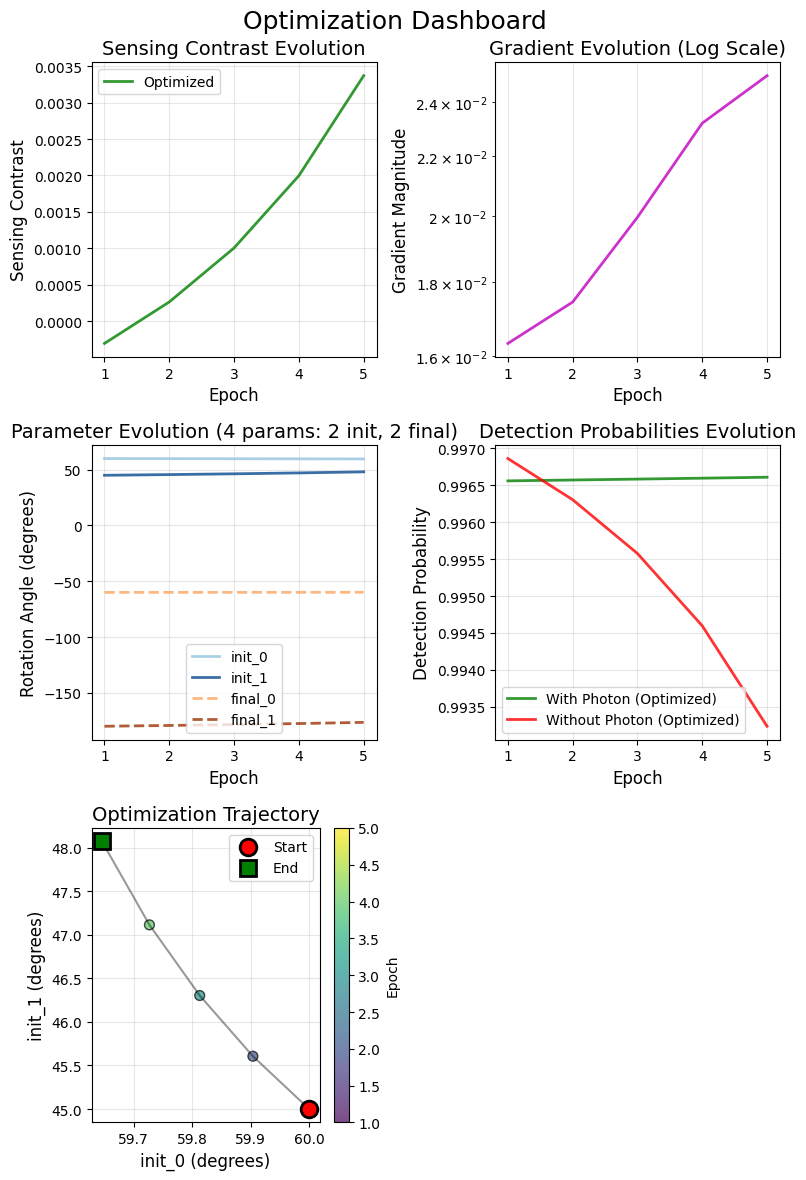

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_probabilities=True,
    figsize=(8, 12)
)
plt.show()
